# Composer Classification with CNN and LSTM

This notebook builds and trains two deep-learning classifiers on `train_features.csv` to predict **Bach, Beethoven, Chopin, or Mozart**.

Validated held-out results from the supplied file:

| Model | Test accuracy | Macro F1 |
|---|---:|---:|
| 1D CNN | 0.886 | 0.809 |
| LSTM | 0.719 | 0.625 |

The identifier columns are deliberately excluded because their text contains composer information. The models use only numeric musical features.

In [1]:
# If TensorFlow is missing, run this once, then restart the kernel:
# %pip install tensorflow pandas scikit-learn matplotlib seaborn joblib

import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

I0000 00:00:1784861659.790970     276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784861659.857654     276 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784861661.819088     276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


## 1. Load and inspect the data



In [2]:
candidates = [
    Path('train_features.csv'),
    Path('upload/train_features.csv'),
    Path('../upload/train_features.csv'),
]
CSV_PATH = next((path for path in candidates if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError('Place train_features.csv beside this notebook or in an upload folder.')

df = pd.read_csv("train_features.csv")
print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
display(df.head())
display(df['composer'].value_counts().rename('count').to_frame())

Shape: (1138, 63)
Missing values: 0
Duplicate rows: 0


,composer,filename,tempo,num_notes,num_chords,avg_pitch,pitch_range,avg_duration,avg_velocity,note_density,...,gm_ensemble_track_count,gm_brass_track_count,gm_reed_track_count,gm_pipe_track_count,gm_synth_lead_track_count,gm_synth_pad_track_count,gm_synth_effects_track_count,gm_ethnic_track_count,gm_percussive_track_count,gm_sound_effects_track_count
0,Bach,Bwv0806 English Suite n1 03mov .mid,272.676782,858,711,63.976690,50,0.294022,106.995338,8.555041,...,0,0,0,0,0,0,0,0,0,0
1,Bach,060800b_ .mid,264.030281,698,371,61.931232,41,0.407495,96.000000,9.222825,...,0,0,0,0,0,0,0,0,0,0
2,Bach,028200b_.mid,148.571448,149,58,61.362416,36,0.797625,96.000000,4.304445,...,0,0,0,0,0,0,0,0,0,0
3,Bach,010602b_.mid,147.671381,1606,321,66.707970,46,0.572140,96.000000,12.166679,...,0,0,0,0,0,0,0,0,0,0
4,Bach,Bwv1058 Harpsichord Concerto n7 2mov.mid,218.947368,2435,657,58.815606,62,0.511512,91.531828,8.822464,...,3,0,0,0,0,0,0,0,0,0


,count
composer,
Bach,716
Mozart,179
Beethoven,148
Chopin,95


## 2. Preprocess and split

- `composer` is the target.
- `filename` and `relative_path` are excluded to prevent label leakage.
- The split is stratified so each composer is represented proportionally.
- Constant-column removal and standardization are learned from training data only.

In [3]:
TARGET = 'composer'
IDENTIFIERS = ['filename', 'relative_path']

X_df = df.drop(columns=[TARGET, *IDENTIFIERS]).select_dtypes(include='number')
y_text = df[TARGET].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
class_names = label_encoder.classes_
row_indices = np.arange(len(df))

train_val_idx, test_idx = train_test_split(
    row_indices, test_size=0.20, random_state=SEED, stratify=y
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.20, random_state=SEED, stratify=y[train_val_idx]
)

train_variances = X_df.iloc[train_idx].var(axis=0)
feature_columns = train_variances[train_variances > 0].index.tolist()
constant_columns = train_variances[train_variances == 0].index.tolist()
X_df = X_df[feature_columns].astype('float32')

scaler = StandardScaler()
X_train_2d = scaler.fit_transform(X_df.iloc[train_idx]).astype('float32')
X_val_2d = scaler.transform(X_df.iloc[val_idx]).astype('float32')
X_test_2d = scaler.transform(X_df.iloc[test_idx]).astype('float32')
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print('Classes:', class_names.tolist())
print('Split sizes:', len(train_idx), len(val_idx), len(test_idx))
print('Retained features:', len(feature_columns))
print('Removed constants:', constant_columns)

Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
Split sizes: 728 182 228
Retained features: 57
Removed constants: ['gm_ethnic_track_count', 'gm_percussive_track_count', 'gm_sound_effects_track_count']


In [4]:
# CNN: one feature per sequence position.
X_train_cnn = X_train_2d[..., np.newaxis]
X_val_cnn = X_val_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

# LSTM: 57 features grouped into 19 ordered steps with 3 channels.
assert X_train_2d.shape[1] % 3 == 0
lstm_steps = X_train_2d.shape[1] // 3
X_train_lstm = X_train_2d.reshape(-1, lstm_steps, 3)
X_val_lstm = X_val_2d.reshape(-1, lstm_steps, 3)
X_test_lstm = X_test_2d.reshape(-1, lstm_steps, 3)

classes = np.arange(len(class_names))
balanced = compute_class_weight('balanced', classes=classes, y=y_train)
lstm_class_weight = {int(i): float(w) for i, w in zip(classes, balanced)}
cnn_class_weight = {int(i): float(np.sqrt(w)) for i, w in zip(classes, balanced)}

print('CNN shape:', X_train_cnn.shape)
print('LSTM shape:', X_train_lstm.shape)
print('LSTM class weights:', lstm_class_weight)

CNN shape: (728, 57, 1)
LSTM shape: (728, 19, 3)
LSTM class weights: {0: 0.39737991266375544, 1: 1.9157894736842105, 2: 2.9836065573770494, 3: 1.5964912280701755}


## 3. Build and train the 1D CNN

In [5]:
n_classes = len(class_names)
n_features = X_train_2d.shape[1]

cnn_model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(24, kernel_size=3, padding='same', activation='relu'),
    Conv1D(32, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dropout(0.30),
    Dense(48, activation='relu'),
    Dropout(0.20),
    Dense(n_classes, activation='softmax'),
], name='composer_cnn')

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
cnn_model.summary()

E0000 00:00:1784768268.147279     265 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "composer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 57, 24)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 57, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │        43,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,684 (178.45 KB)

 Trainable params: 45,684 (178.45 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
    ]

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=64,
    class_weight=cnn_class_weight,
    callbacks=callbacks(),
    verbose=1,
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6003 - loss: 1.1319 - val_accuracy: 0.6703 - val_loss: 0.8483 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7280 - loss: 0.8806 - val_accuracy: 0.7692 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7816 - loss: 0.7230 - val_accuracy: 0.8132 - val_loss: 0.5868 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8173 - loss: 0.6091 - val_accuracy: 0.8462 - val_loss: 0.5104 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8132 - loss: 0.5548 - val_accuracy: 0.8571 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8379 - loss: 0.4833 - val_accuracy: 0.8681 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8626 - loss: 0.4653 - val_accurac

In [ ]:
##4. Build and train the LSTM

In [7]:
lstm_model = Sequential([
    Input(shape=(lstm_steps, 3)),
    LSTM(32),
    Dropout(0.25),
    Dense(48, activation='relu'),
    Dropout(0.20),
    Dense(n_classes, activation='softmax'),
], name='composer_lstm')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=40,
    batch_size=64,
    class_weight=lstm_class_weight,
    callbacks=callbacks(),
    verbose=1,
)

Model: "composer_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,388 (24.95 KB)

 Trainable params: 6,388 (24.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3242 - loss: 1.3789 - val_accuracy: 0.5659 - val_loss: 1.3579 - learning_rate: 0.0010
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5536 - loss: 1.3483 - val_accuracy: 0.6593 - val_loss: 1.3108 - learning_rate: 0.0010
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5838 - loss: 1.3174 - val_accuracy: 0.6538 - val_loss: 1.2352 - learning_rate: 0.0010
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6058 - loss: 1.2640 - val_accuracy: 0.6319 - val_loss: 1.1325 - learning_rate: 0.0010
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6085 - loss: 1.2263 - val_accuracy: 0.6868 - val_loss: 1.0503 - learning_rate: 0.0010
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6126 - loss: 1.1677 - val_accuracy: 0.6593 - val_loss: 1.0315 - learning_rate: 0.0010
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5797 - loss: 1.1423 - val_acc

## 5. Evaluate both models on the held-out test set

In [8]:
def evaluate_model(name, model, X_test):
    probabilities = model.predict(X_test, verbose=0)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, predictions, average='macro', zero_division=0
    )
    result = {
        'model': name,
        'accuracy': accuracy_score(y_test, predictions),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }
    print(f'\n{name}')
    print(classification_report(y_test, predictions, target_names=class_names, zero_division=0))
    return result, predictions

cnn_result, cnn_pred = evaluate_model('CNN', cnn_model, X_test_cnn)
lstm_result, lstm_pred = evaluate_model('LSTM', lstm_model, X_test_lstm)
results_df = pd.DataFrame([cnn_result, lstm_result]).set_index('model')
display(results_df.style.format('{:.3f}'))


CNN
              precision    recall  f1-score   support

        Bach       0.96      0.97      0.96       143
   Beethoven       0.65      0.73      0.69        30
      Chopin       0.81      0.68      0.74        19
      Mozart       0.71      0.67      0.69        36

    accuracy                           0.86       228
   macro avg       0.78      0.76      0.77       228
weighted avg       0.87      0.86      0.86       228


LSTM
              precision    recall  f1-score   support

        Bach       0.89      0.76      0.82       143
   Beethoven       0.44      0.63      0.52        30
      Chopin       0.55      0.63      0.59        19
      Mozart       0.45      0.50      0.47        36

    accuracy                           0.69       228
   macro avg       0.58      0.63      0.60       228
weighted avg       0.73      0.69      0.71       228



,accuracy,macro_precision,macro_recall,macro_f1
model,,,,
CNN,0.864,0.781,0.762,0.769
LSTM,0.693,0.581,0.632,0.600


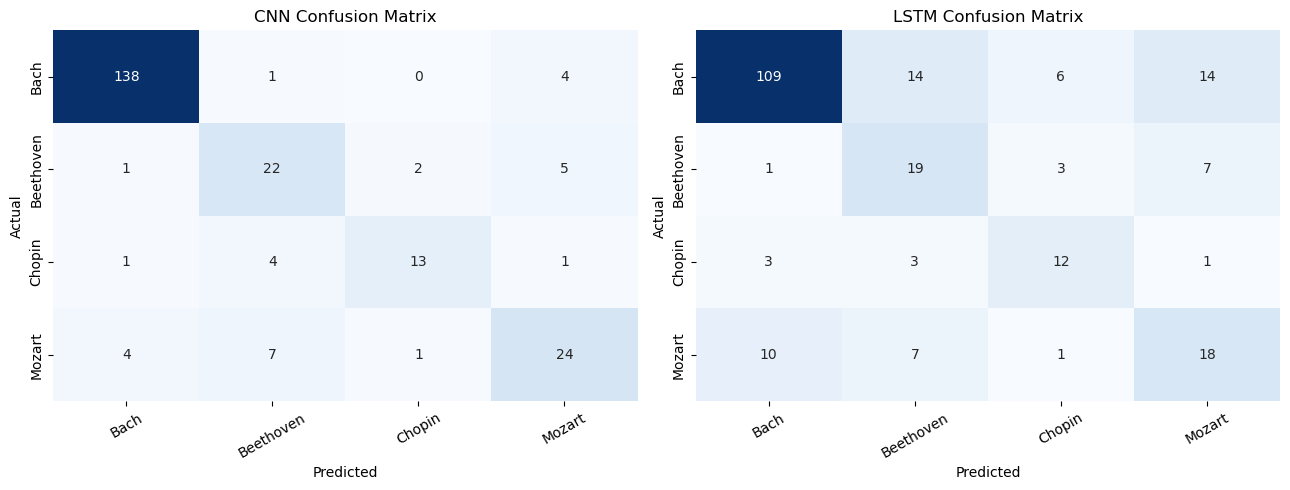

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, pred in zip(axes, ['CNN', 'LSTM'], [cnn_pred, lstm_pred]):
    sns.heatmap(
        confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set(title=f'{name} Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

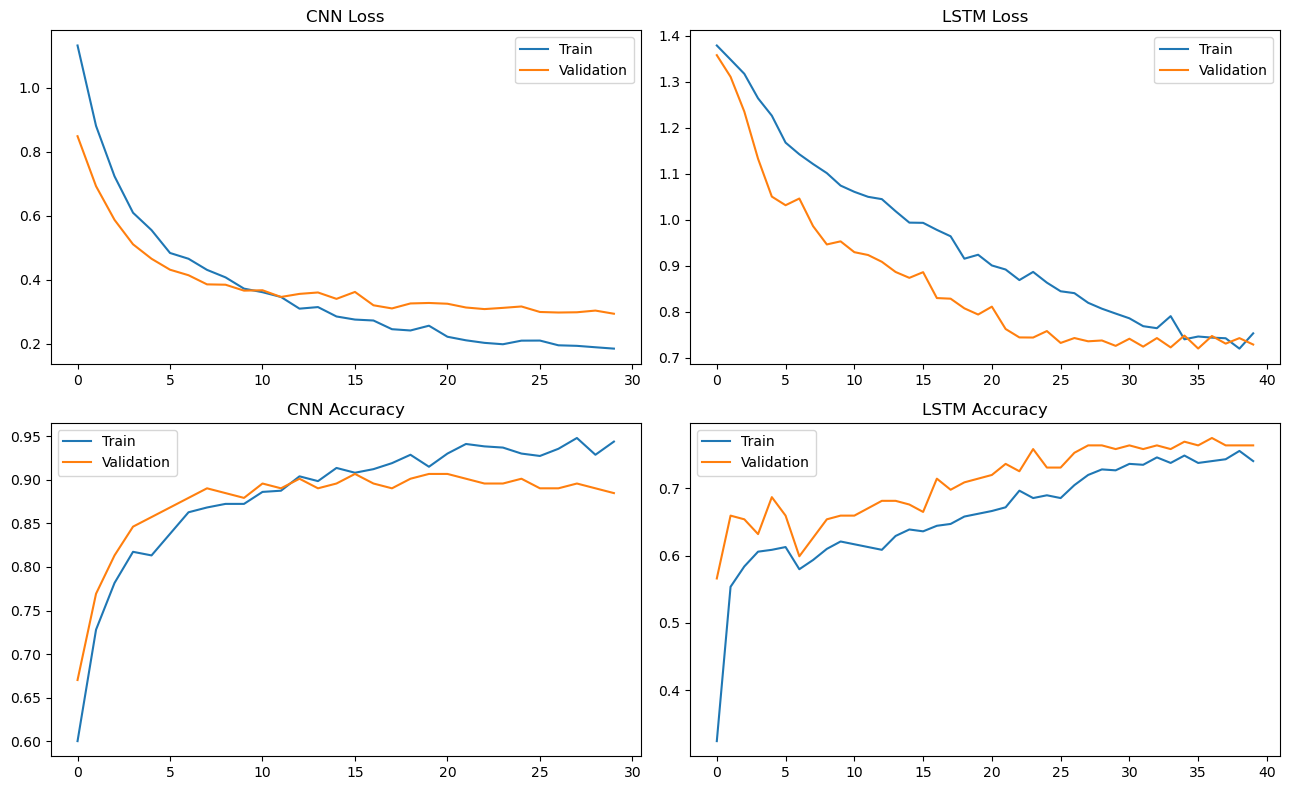

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for col, (name, history) in enumerate([('CNN', cnn_history), ('LSTM', lstm_history)]):
    axes[0, col].plot(history.history['loss'], label='Train')
    axes[0, col].plot(history.history['val_loss'], label='Validation')
    axes[0, col].set_title(f'{name} Loss')
    axes[0, col].legend()
    axes[1, col].plot(history.history['accuracy'], label='Train')
    axes[1, col].plot(history.history['val_accuracy'], label='Validation')
    axes[1, col].set_title(f'{name} Accuracy')
    axes[1, col].legend()
plt.tight_layout()
plt.show()

## 6. Save the trained models and preprocessing objects

In [11]:
OUTPUT_DIR = Path('trained_models')
OUTPUT_DIR.mkdir(exist_ok=True)
cnn_model.save(OUTPUT_DIR / 'composer_cnn.keras')
lstm_model.save(OUTPUT_DIR / 'composer_lstm.keras')
joblib.dump(
    {'scaler': scaler, 'label_encoder': label_encoder, 'feature_columns': feature_columns},
    OUTPUT_DIR / 'composer_preprocessor.joblib',
)
results_df.to_csv(OUTPUT_DIR / 'model_results.csv')
print('Saved to:', OUTPUT_DIR.resolve())

Saved to: /home/032f12c5-1ba7-4365-a7b7-24a6c4fc64f7/trained_models


## Interpretation

The CNN is expected to outperform the LSTM on this dataset because the CSV contains fixed, aggregate features rather than chronological note events. The convolution layers can learn local patterns across related feature groups while the flattened representation preserves each feature's position. For a more natural LSTM experiment, extract ordered MIDI note sequences—such as pitch, duration, velocity, and inter-onset interval per event—and pad or window those sequences before training.